# Table of Contents

1. Libraries
2. Data Loading and Formatting
3. Data Processing
4. Analysis
5. Results

---

# 1. Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


# Saving Directory

if not os.path.exists("img"):
    os.mkdir("img")

saveFigs = False

saveData   = False
procFolder = "./Data/processedData"

---

# 2. Data Loading and Formatting

In [2]:
dataFolder = "./Data/rawData"

file_names = { 
    
    "Group 1": ("Adrian_Marc_Maria.csv", "latitude", "longitude", "elevation"),
    "Group 2": ("laura_parra_judit_gorgori.csv", "Y", "X", "ele"),
    "Group 3": ("pau-gargallo.csv", "latitude", "longitude", "elevation"),
    "Group 4": ("polanderruta.csv", "latitude", "longitude", "elevation"),
    "Group 5": ("zona-universitaria-pqs.csv", "latitude", "longitude", "elevation")
}

# Color-blind friendly palette

colors = {
    "Group 1": "#EE6677",  # rojo-rosa
    "Group 2": "#CCBB44",  # amarillo
    "Group 3": "#228833",  # verde
    "Group 4": "#AA3377",  # púrpura
    "Group 5": "#332288",  # azul
}


## 2.2. Data Formatting

We want to create a dictionary that contains the data from the CSV files. The keys of the dictionary will be Group X, where X is the group number, and the values will be the corresponding data from the CSV files. However, we want to unify the format of the data in the CSV files, as they may have different structures. To achieve this, we will create a function that reads the CSV files and formats the data into a consistent structure before adding it to the dictionary.


<div align="center">

**Local equirectangular projection** 

(degrees $\to$ meters), with origin at the track centroid $(\bar\varphi, \bar\lambda)$

</div>

$$
x = R \, \cos(\bar\varphi)\,\big(\lambda - \bar\lambda\big), 
\qquad 
y = R \, \big(\varphi - \bar\varphi\big)
$$

where $\varphi$ is the latitude, $\lambda$ the longitude (in radians), $R = 6\,371\,000\ \mathrm{m}$ the Earth's radius, and $\bar\varphi,\bar\lambda$ the mean latitude and longitude of the track. The factor $\cos(\bar\varphi)$ corrects for the shortening of the meridians with latitude.

In [3]:
# --- Data formating function ---

R = 6.371 * 10**6  # Earth's radius (m)

def formatData(fname, latc, lonc, elec):

    # Data Loading

    df = pd.read_csv(f"{dataFolder}/{fname}")

    # DF Structure

    out = pd.DataFrame({
            "lat":  pd.to_numeric(df[latc], errors="coerce"),
            "lon":  pd.to_numeric(df[lonc], errors="coerce"),
            "ele":  pd.to_numeric(df[elec], errors="coerce"),
            "time": pd.to_datetime(df["time"].astype(str).str.replace("/", "-"),
                                utc=True, format="mixed", errors="coerce"),
        })
    
    # DF Cleaning

    out = (out.dropna(subset=["lat", "lon", "time"])
            .sort_values("time").drop_duplicates("time")
            .reset_index(drop=True))
    
    # Projection (degrees -> m) (origin = center of the track)

    lat0, lon0 = np.radians(out["lat"].mean()), np.radians(out["lon"].mean())
    out["x"] = R * np.cos(lat0) * (np.radians(out["lon"]) - lon0)
    out["y"] = R * (np.radians(out["lat"]) - lat0)

    return out

# --- Data formatting application ---

dataDF = {}
for name, info in file_names.items():

    dataDF[name] = formatData(*info)

# --- Common centroid --- (to plot all tracks)

# Center of all tracks

all_lat = np.concatenate([df["lat"].values for df in dataDF.values()])
all_lon = np.concatenate([df["lon"].values for df in dataDF.values()])
lat0, lon0 = np.radians(all_lat.mean()), np.radians(all_lon.mean())

# Common Origin 

def to_common_xy(df, lat0, lon0):
    xm = R * np.cos(lat0) * (np.radians(df["lon"]) - lon0)
    ym = R * (np.radians(df["lat"]) - lat0)
    return xm, ym

## 2.3. Trajectories plot (2D)

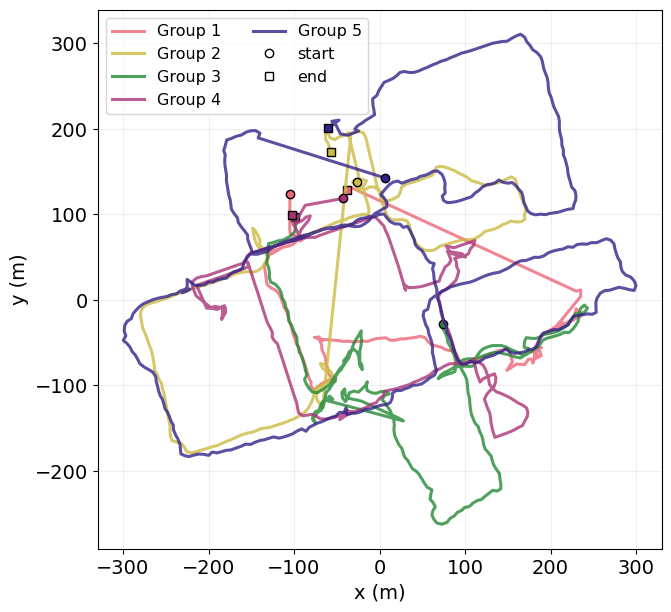

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, df in dataDF.items():

    xm, ym = to_common_xy(df, lat0, lon0)
    ax.plot(xm, ym, color=colors[name], lw=2.2, alpha=.8, label=name)
    ax.plot(xm.iloc[0],  ym.iloc[0],  "o", color=colors[name], mec="k")
    ax.plot(xm.iloc[-1], ym.iloc[-1], "s", color=colors[name], mec="k")

ax.plot([], [], "o", color="white", mec="k", label="start")
ax.plot([], [], "s", color="white", mec="k", label="end")
ax.set_aspect("equal")                       
ax.set_xlabel("x (m)", fontsize=14)
ax.set_ylabel("y (m)", fontsize=14)
ax.tick_params(labelsize=14)
# ax.set_title("Pedestrian tracks")
ax.legend(ncol=2, fontsize=11.5)
ax.grid(which="both", alpha=.2)
plt.show()

if saveFigs:
    fig.savefig("img/trajectories.png", dpi=600, bbox_inches="tight")

---

# 3. Data Processing

We want to compute the following quantities for each track:

- dt -> time difference between consecutive points (seconds)

- seg -> segment label that increases each time the logger went silent for more than 120 s; splits the track so gaps aren't treated as movement (GPS issues)

- step -> distance travelled from the previous point (in meters); set to NaN across segment gaps

- speed -> step / dt ->  instantaneous walking speed, with impossible values (>8 m/s) removed as GPS noise.

- heading -> direction of movement (angle in radians)

- turn -> change in heading (angle in radians); set to NaN across segment gaps

- cum_dist ->  running total of distance walked along the track (m); flat stretches reveal pauses.

- elapsed -> seconds since the start of the track; the x-axis for time-based plots

In [5]:
# --- Gap and spurious spikes detection ---

gap_time, spike_velocity = 120, 8   

# --- Metrics computation function ---

def computeDerivedDF(df):

    df = df.sort_values("time").reset_index(drop=True).copy()

    # dt

    df["dt"] = df["time"].diff().dt.total_seconds()

    # seg

    df["seg"] = (df["dt"] > gap_time).cumsum()

    # step 

    df["step"] = np.sqrt(df["x"].diff()**2 + df["y"].diff()**2)
    df.loc[df["dt"] > gap_time, "step"] = np.nan      # don't count the jump across a gap

    # speed 

    df["speed"] = df["step"] / df["dt"]
    df.loc[df["speed"] > spike_velocity, "speed"] = np.nan

    # heading (radians)

    df["heading"] = np.arctan2(df["y"].diff(), df["x"].diff())

    # turning angle (radians, -pi..pi)

    df["turn"] = (df["heading"].diff() + np.pi) % (2*np.pi) - np.pi

    # cum_dist 

    df["cum_dist"] = df["step"].fillna(0).cumsum()

    # elapsed time (s) within the track

    df["elapsed"]  = (df["time"] - df["time"].iloc[0]).dt.total_seconds()

    return df

# New Dictionary

dataDeriv = {name: computeDerivedDF(df) for name, df in dataDF.items()}


In [6]:
# Number of segments

print("NUMBER OF SEGMENTS")

for name, df in dataDeriv.items():
    print(name, "->", df["seg"].nunique(), "segmentos")

print("\n")

# Mean velocity

print("MEAN VELOCITY")

for name, df in dataDeriv.items():
    print(name, "->", round(df["speed"].median(), 2), "m/s")

NUMBER OF SEGMENTS
Group 1 -> 2 segmentos
Group 2 -> 5 segmentos
Group 3 -> 2 segmentos
Group 4 -> 5 segmentos
Group 5 -> 1 segmentos


MEAN VELOCITY
Group 1 -> 1.25 m/s
Group 2 -> 1.16 m/s
Group 3 -> 1.18 m/s
Group 4 -> 1.31 m/s
Group 5 -> 1.38 m/s


## Data saving (csv)

In [7]:
def _safe(name):                       # "Group 1" -> "Group_1"
    return name.replace(" ", "_")

if saveData: # the DataFrames generated during formatting and processing

    os.makedirs(f"{procFolder}/DerivedDF/formated", exist_ok=True)
    os.makedirs(f"{procFolder}/DerivedDF/derived",  exist_ok=True)

    for name, df in dataDF.items():        # cleaned + projected tracks
        df.to_csv(f"{procFolder}/DerivedDF/formated/{_safe(name)}_formatted.csv", index=False)

    for name, df in dataDeriv.items():     # per-step metrics
        df.to_csv(f"{procFolder}/DerivedDF/derived/{_safe(name)}_derived.csv", index=False)

---

# 4. Analysis

## 4.1. MSD

In this case, we need to be careful with the MSD calculation, as the sampling rate is not constant (4-5s, with gaps). Therefore, equal point separations do not correspond to equal time intervals. Consequently, we bin point pairs by their real time lag τ instead of by step number, making the MSD insensitive to the uneven logging cadence.

In [8]:
# --- Log-spaced bins ---

bins = np.logspace(np.log10(4), np.log10(600), 18)   # from ~sampling resolution (4 s) up to 600 s
cen  = np.sqrt(bins[:-1] * bins[1:])                 # bin centers
min_count = 20                                       # drop under-populated bins

# --- Time-averaged Mean-Squared Displacement ---

def tamsd_acc(df): # Accumulate Σ|Δr|² and the number of pairs per τ-bin, over all within-segment pairs.
    
    suma = np.zeros(len(cen))
    n    = np.zeros(len(cen))

    for _, seg in df.groupby("seg"):
        if len(seg) < 2:
            continue
        x = seg["x"].values
        y = seg["y"].values
        t = seg["elapsed"].values

        for i in range(len(t) - 1):
            dtau = t[i+1:] - t[i]                       # lags from point i
            dr2  = (x[i+1:] - x[i])**2 + (y[i+1:] - y[i])**2
            idx  = np.digitize(dtau, bins) - 1          # which bin each lag falls in
            ok   = (idx >= 0) & (idx < len(cen))
            np.add.at(suma, idx[ok], dr2[ok])
            np.add.at(n,    idx[ok], 1)

    return suma, n

# --- Finish computation --- (Normalization and cleaning)

def finish(suma, n): # Σ/N per bin, blanking bins with fewer than min_count pairs.
    
    out = suma / np.where(n > 0, n, np.nan)
    out[n < min_count] = np.nan
    
    return out

# Individual curves

acc = {name: tamsd_acc(df) for name, df in dataDeriv.items()}
msd = {name: finish(s, n) for name, (s, n) in acc.items()}

# Pooled curve

suma_tot = np.sum([s for s, _ in acc.values()], axis=0)
n_tot    = np.sum([n for _, n in acc.values()], axis=0)
ens = finish(suma_tot, n_tot)

In addtion, we want to compute the slope of the MSD curve in log-log scale, which is related with the type of movement. In practice the exponent is obtained from a linear least-squares fit in logarithmic scale,
$$

\log_{10}\langle \Delta r^2 \rangle = \alpha \log_{10}\tau + c,

$$
with $\alpha$ the slope.

In [9]:
# Time windows limits

short_lo, short_hi = 4, 30
long_lo, long_hi = 100, 550

# Fitting function

def fit_slope(lo, hi):

    mask = (cen >= lo) & (cen <= hi) & (ens > 0) 
    logx = np.log10(cen[mask])
    logy = np.log10(ens[mask])
    slope, intercept = np.polyfit(logx, logy, 1)

    return slope, intercept

# Fitting computation

slope_short, int_short = fit_slope(short_lo, short_hi)   # short lag -> ~ballistic
slope_long,  int_long  = fit_slope(long_lo,  long_hi)    # long lag  -> ~diffusive

## 4.2. Turning Angle Distribution

We want to collect the turning angles $\theta$ between consecutive steps and describe their distribution with a von Mises law, $p(\theta)\propto e^{\kappa\cos\theta}$, the circular analogue of a Gaussian, where $\kappa$ measures the persistence of the motion ($\kappa = 0$ corresponding to a memoryless random walk). Thus, we can estimate $\kappa$ from the mean resultant length $\bar R=|\langle e^{i\theta}\rangle|$ by solving $\bar R = I_1(\kappa)/I_0(\kappa)$, the maximum-likelihood condition for the von Mises distribution.

In [10]:
from scipy.special import i0, i1
from scipy.optimize import brentq

# Turning angles

min_step = 1.0   
turns = np.concatenate([
    df.loc[df["step"] > min_step, "turn"].dropna().values
    for df in dataDeriv.values()])

# Mean resultant length -> kappa  (von Mises: Rbar = I1(k)/I0(k))

Rbar  = np.abs(np.mean(np.exp(1j * turns)))
kappa = brentq(lambda k: i1(k)/i0(k) - Rbar, 1e-6, 700)
print(f"N turns = {len(turns)},  Rbar = {Rbar:.3f},  kappa = {kappa:.2f}")


N turns = 1493,  Rbar = 0.837,  kappa = 3.43


## 4.3. Flight Length Distribution

We test whether our trajectories show **Lévy-flight** signatures: motion made of many short moves and rare long, straight excursions, with flight lengths following a heavy power-law tail $p(L)\propto L^{-\gamma}$ rather than the exponential tail of a plain random walk. We split each track into flights (merging steps while the heading stays within $\Theta=30^\circ$), fit the tail above $x_{\min}$ with the Hill estimator and compare the power law against exponential and lognormal alternatives via KS distance and Vuong's test.

In [11]:
from scipy import stats

theta_lim = np.radians(30)

# --- Segment each track into flights (heading kept within THETA) ---

def flights_of(df):

    out = []

    for _, seg in df.groupby("seg"):

        x = seg["x"].values
        y = seg["y"].values

        if len(x) < 2: continue     # skip segments with less than 2 points

        # Flight starts at the first point; h0 = its initial heading

        sx, sy = x[0], y[0]
        h0 = np.arctan2(y[1]-y[0], x[1]-x[0])

        for i in range(1, len(x)):  # loop over the steps of the segment

            hi  = np.arctan2(y[i]-y[i-1], x[i]-x[i-1])          # heading of the current step
            dev = abs((hi - h0 + np.pi) % (2*np.pi) - np.pi)    # angular deviation, wrapped to [0, pi]

            if dev > theta_lim:                                     # sharp turn -> close current flight

                L = np.hypot(x[i-1]-sx, y[i-1]-sy)              # straight-line length start -> turning point
                if L > 0: out.append(L)

                sx, sy, h0 = x[i-1], y[i-1], hi                 # restart a new flight from the turning point

        L = np.hypot(x[-1]-sx, y[-1]-sy)                        # close the trailing flight at the segment end
        if L > 0: out.append(L)
        
    return np.array(out)

# --- Pool all flight lengths ---

flights = np.concatenate([flights_of(df) for df in dataDeriv.values()])
flights = flights[flights > 0]

# --- Tail region ---

p    = 70                                
xmin = np.percentile(flights, p)
tail = np.sort(flights[flights >= xmin]); n = len(tail)

# --- Power law (Hill MLE): p(L) ~ L^-alpha ---

alpha = 1 + n / np.sum(np.log(tail/xmin))
SE    = (alpha - 1) / np.sqrt(n)
ll_pl = np.log((alpha-1)/xmin) - alpha*np.log(tail/xmin)

# --- Exponential distribution on [xmin, inf) ---

lam    = 1 / np.mean(tail - xmin)
ll_exp = np.log(lam) - lam*(tail - xmin)

# --- Lognormal distribution truncated at [xmin, inf) ---

s, loc, scale = stats.lognorm.fit(tail, floc=0)
Sxmin = stats.lognorm.sf(xmin, s, loc, scale)
ll_ln = stats.lognorm.logpdf(tail, s, loc, scale) - np.log(Sxmin)

# --- Goodness of fit (KS) and likelihood ratio test (Vuong) ---

emp = np.arange(1, n+1) / n
ks_pl  = np.max(np.abs(emp - (1 - (tail/xmin)**(-(alpha-1)))))
ks_exp = np.max(np.abs(emp - (1 - np.exp(-lam*(tail-xmin)))))
ks_ln  = np.max(np.abs(emp - (stats.lognorm.cdf(tail,s,loc,scale) - stats.lognorm.cdf(xmin,s,loc,scale))/Sxmin))

def vuong(a, b):                            
    d = a - b
    return np.sum(d), np.sum(d)/(np.std(d, ddof=1)*np.sqrt(n))

R_ln,  z_ln  = vuong(ll_pl, ll_ln)
R_exp, z_exp = vuong(ll_pl, ll_exp)

# --- Report ---

print(f"xmin = {xmin:.1f} m   Tail sample size = {n}")
print(f"Power law  alpha = {alpha:.2f} ± {SE:.2f}")
print(f"KS:  power law {ks_pl:.3f} | lognormal {ks_ln:.3f} | exponential {ks_exp:.3f}  (lower = better)")
print(f"Vuong PL vs lognormal:   z = {z_ln:+.2f}    (|z|<1.96 => indistinguishable)")
print(f"Vuong PL vs exponential: z = {z_exp:+.2f}   (|z|<1.96 => indistinguishable)")

xmin = 22.4 m   Tail sample size = 117
Power law  alpha = 2.39 ± 0.13
KS:  power law 0.115 | lognormal 0.176 | exponential 0.093  (lower = better)
Vuong PL vs lognormal:   z = +0.55    (|z|<1.96 => indistinguishable)
Vuong PL vs exponential: z = -1.19   (|z|<1.96 => indistinguishable)


## Data saving (csv)

In [12]:
if saveData:

    plotDir = f"{procFolder}/plotData"
    os.makedirs(plotDir, exist_ok=True)

    # --- Trajectories -- (Fig. 1)

    traj = []
    for name, df in dataDF.items():
        xm, ym = to_common_xy(df, lat0, lon0)
        traj.append(pd.DataFrame({"group": name, "x_m": xm.values, "y_m": ym.values}))
    pd.concat(traj, ignore_index=True).to_csv(f"{plotDir}/trajectories.csv", index=False)

    # --- MSD curves and fits -- (Fig. 2a)

    if "msd" in globals():
        msd_df = pd.DataFrame({"tau_s": cen})
        for name, curve in msd.items():
            msd_df[_safe(name)] = curve
        if "ens" in globals():
            msd_df["Pooled"] = ens
        msd_df.to_csv(f"{plotDir}/MSD_curves.csv", index=False)

        if "slope_short" in globals():
            pd.DataFrame({
                "window":    ["short", "long"],
                "lag_lo_s":  [short_lo, long_lo],
                "lag_hi_s":  [short_hi, long_hi],
                "slope":     [slope_short, slope_long],
                "intercept": [int_short, int_long],
            }).to_csv(f"{plotDir}/MSD_fit.csv", index=False)

    # --- von Mises -- empirical histogram + fitted density (Fig. 2b)

    if "turns" in globals() and "kappa" in globals():
        bb = np.linspace(-np.pi, np.pi, 49)
        cnt, e = np.histogram(turns, bins=bb, density=True)
        ctr = (e[:-1] + e[1:]) / 2
        pd.DataFrame({"angle_rad": ctr, "angle_deg": np.degrees(ctr),
                      "density": cnt}).to_csv(f"{plotDir}/vonMises_hist.csv", index=False)

        th = np.linspace(-np.pi, np.pi, 400)
        vm = np.exp(kappa*np.cos(th)) / (2*np.pi*i0(kappa))
        pd.DataFrame({"theta_rad": th, "theta_deg": np.degrees(th),
                      "density": vm}).to_csv(f"{plotDir}/vonMises_fit.csv", index=False)

        pd.DataFrame({"N_turns": [len(turns)],
                      "Rbar":    [Rbar if "Rbar" in globals() else np.nan],
                      "kappa":   [kappa]}).to_csv(f"{plotDir}/vonMises_params.csv", index=False)

    # --- Levy flights -- empirical CCDF, model curves, fit parameters (Fig. 2c)

    if "tail" in globals():
        ccdf = 1 - np.arange(n)/n
        pd.DataFrame({"L_m": tail, "ccdf": ccdf}).to_csv(
            f"{plotDir}/LevyFlight_ccdf.csv", index=False)

        xx = np.logspace(np.log10(xmin), np.log10(tail.max()), 60)
        pd.DataFrame({
            "L_m":         xx,
            "power_law":   (xx/xmin)**(-(alpha-1)),
            "lognormal":   stats.lognorm.sf(xx, s, loc, scale)/Sxmin,
            "exponential": np.exp(-lam*(xx-xmin)),
        }).to_csv(f"{plotDir}/LevyFlight_models.csv", index=False)

        pd.DataFrame({
            "xmin_m":           [xmin],
            "n_tail":           [n],
            "alpha":            [alpha],
            "alpha_SE":         [SE   if "SE"   in globals() else np.nan],
            "lambda_exp":       [lam],
            "lognorm_s":        [s],
            "lognorm_scale":    [scale],
            "z_vs_lognormal":   [z_ln  if "z_ln"  in globals() else np.nan],
            "z_vs_exponential": [z_exp if "z_exp" in globals() else np.nan],
        }).to_csv(f"{plotDir}/LevyFlight_fit_params.csv", index=False)


---

# 5. Results

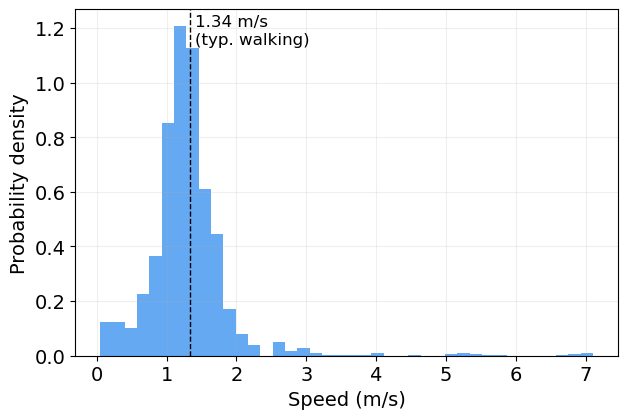

median = 1.26 m/s
mean   = 1.32 m/s
std    = 0.68 m/s
95th percentile = 2.03 m/s


In [13]:
all_speed = np.concatenate([df["speed"].dropna().values for df in dataDeriv.values()])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(all_speed, bins=40, density=True, color="#499af0", alpha=.85)
ax.axvline(1.34, ls="--", color="k", lw=1)
ax.text(1.4, ax.get_ylim()[1]*.9, "1.34 m/s\n(typ. walking)", fontsize=12)
ax.set_xlabel("Speed (m/s)", fontsize=14)
ax.set_ylabel("Probability density", fontsize=14)
ax.tick_params(labelsize=14)
ax.grid(which="both", alpha=.2)
plt.show()

print(f"median = {np.median(all_speed):.2f} m/s")
print(f"mean   = {np.mean(all_speed):.2f} m/s")
print(f"std    = {np.std(all_speed, ddof=1):.2f} m/s")
print(f"95th percentile = {np.percentile(all_speed, 95):.2f} m/s")

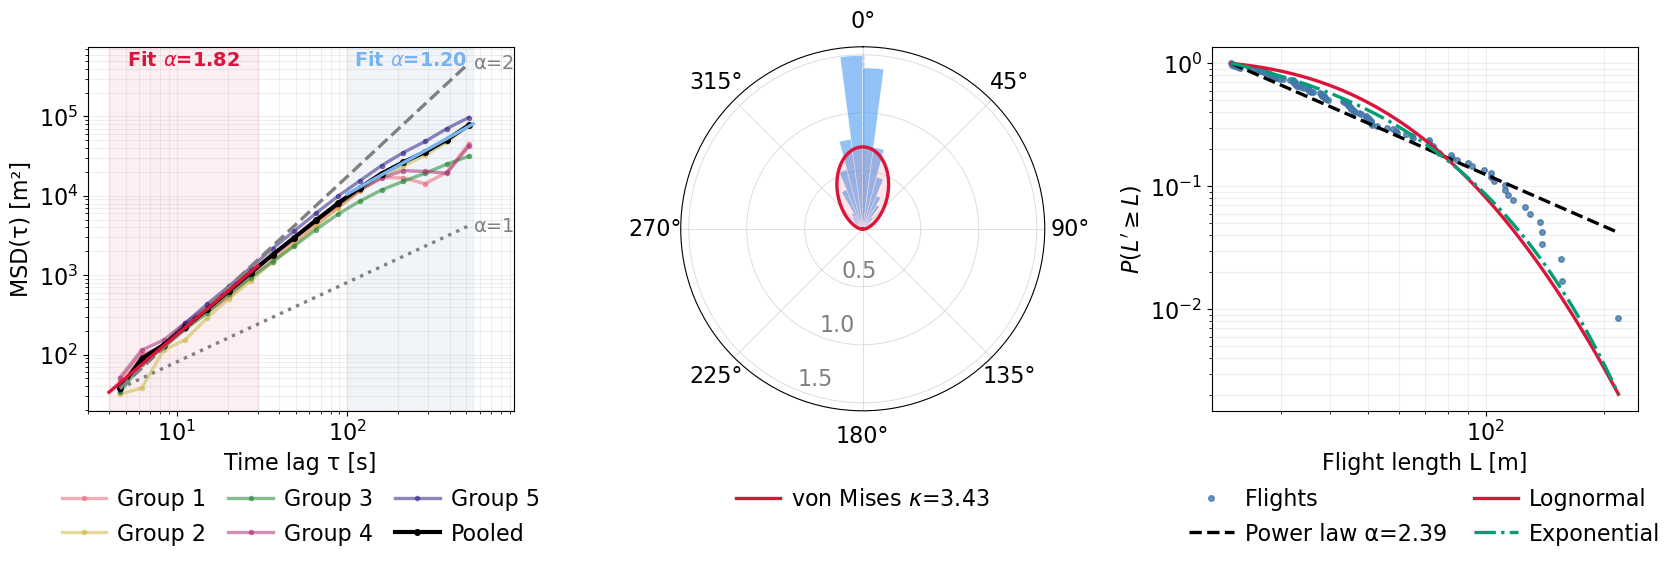

In [14]:
# ======================================================================
# COMBINED FIGURE:  a) MSD   b) Turning angles   c) Flight-length tail
# all legends below + aligned; α annotated inside the MSD bands
# ======================================================================

# --- Canvas ---

fig = plt.figure(figsize=(20, 5.2))
gs = fig.add_gridspec(1, 3, wspace=0.32)


# ======================================================================
# a) TIME-AVERAGED MSD
# ======================================================================

axa = fig.add_subplot(gs[0, 0])

# --- Reference slopes (α=1 diffusive, α=2 ballistic) ---

tau_min = cen[ens > 0][0]; tau_max = cen[ens > 0][-1]; msd0 = ens[ens > 0][0]
tau_ref = np.array([tau_min, tau_max])
guide1  = msd0 * (tau_ref/tau_min)**1
guide2  = msd0 * (tau_ref/tau_min)**2

# --- Individual + pooled curves ---

for name in msd:
    axa.loglog(cen, msd[name], "-o", ms=3, lw=2.4, alpha=0.55, color=colors[name], label=name)
axa.loglog(cen, ens, "k-o", ms=4, lw=3, label="Pooled")

# --- Guide lines and their labels ---

axa.loglog(tau_ref, guide1, color="gray", ls=":",  lw=2.4)
axa.loglog(tau_ref, guide2, color="gray", ls="--", lw=2.4)
axa.annotate("α=1", xy=(tau_max, guide1[1]), xytext=(4, 0), textcoords="offset points",
             va="center", color="gray", fontsize=14)
axa.annotate("α=2", xy=(tau_max, guide2[1]), xytext=(4, 0), textcoords="offset points",
             va="center", color="gray", fontsize=14)

# --- Shaded fit windows ---

axa.axvspan(short_lo, short_hi, color="crimson", alpha=0.07)
axa.axvspan(long_lo,  long_hi,  color="#4477AA", alpha=0.07)

# --- Fitted slopes ---

xs = np.array([short_lo, short_hi]); xl = np.array([long_lo, long_hi])
axa.loglog(xs, 10**int_short * xs**slope_short, color="crimson", lw=2.4)
axa.loglog(xl, 10**int_long  * xl**slope_long,  color="#78B3EF", lw=2.4)

# --- Alpha labels inside the shaded bands ---

axa.text(np.sqrt(short_lo*short_hi), 0.99, fr"Fit $\alpha$={slope_short:.2f}",
         transform=axa.get_xaxis_transform(), ha="center", va="top",
         color="crimson", fontsize=14, fontweight="bold")
axa.text(np.sqrt(long_lo*long_hi), 0.99, fr"Fit $\alpha$={slope_long:.2f}",
         transform=axa.get_xaxis_transform(), ha="center", va="top",
         color="#78B3EF", fontsize=14, fontweight="bold")

# --- Axes ---

axa.set_xlabel("Time lag τ [s]", fontsize=16)
axa.set_ylabel("MSD(τ) [m²]", fontsize=16)
axa.tick_params(labelsize=16)
axa.set_xlim(3, 950); axa.grid(which="both", alpha=.2)


# ======================================================================
# b) TURNING-ANGLE DISTRIBUTION (von Mises)
# ======================================================================

axb = fig.add_subplot(gs[0, 1], projection="polar")
axb.set_theta_zero_location("N"); axb.set_theta_direction(-1)

# --- Empirical histogram ---

bb = np.linspace(-np.pi, np.pi, 49)
cnt, e = np.histogram(turns, bins=bb, density=True)
ctr = (e[:-1] + e[1:]) / 2
axb.bar(ctr, cnt, width=np.diff(e), color="#499af0", alpha=.6, edgecolor="white", lw=.5, zorder=2)

# --- Fitted von Mises density ---

th = np.linspace(-np.pi, np.pi, 400)
vm = np.exp(kappa*np.cos(th)) / (2*np.pi*i0(kappa))
axb.fill_between(th, 0, vm, color="crimson", alpha=.10, zorder=3)
axb.plot(th, vm, color="crimson", lw=2.4, zorder=4, label=fr"von Mises $\kappa$={kappa:.2f}")
axb.plot([0, 0], [0, cnt.max()*1.02], color="0.45", lw=1, ls="--", zorder=1)

# --- Polar cosmetics ---

axb.set_thetagrids(range(0, 360, 45), labels=[f"{d}°" for d in range(0, 360, 45)])
axb.set_yticks([0.5, 1.0, 1.5])
axb.set_rlabel_position(202)
axb.tick_params(axis="x", pad=8, labelsize = 16)
axb.tick_params(axis="y", labelsize=16, colors="0.5")
axb.set_ylim(0, cnt.max()*1.05)
axb.grid(color="0.85", lw=.6)
# axb.text(0.5, -0.12, f"N = {len(turns)}    $\\bar R$ = {Rbar:.2f},
#          transform=axb.transAxes, fontsize=16, color="0.4", ha="center", va="top")


# ======================================================================
# c) FLIGHT-LENGTH TAIL (Lévy check)
# ======================================================================

axc = fig.add_subplot(gs[0, 2])

# --- Empirical CCDF ---

ccdf = 1 - np.arange(n)/n
xx = np.logspace(np.log10(xmin), np.log10(tail.max()), 60)
axc.loglog(tail, ccdf, "o", ms=4, color="#4477AA", alpha=0.8, label="Flights")

# --- Candidate models ---

axc.loglog(xx, (xx/xmin)**(-(alpha-1)), "--", lw=2.4, color="black", label=fr"Power law α={alpha:.2f}")
axc.loglog(xx, stats.lognorm.sf(xx, s, loc, scale)/Sxmin, "-", color="crimson", lw=2.4, label="Lognormal")
axc.loglog(xx, np.exp(-lam*(xx-xmin)), "-.", color="#009E73", lw=2.4, label="Exponential")

# --- Axes ---

axc.set_xlabel("Flight length L [m]", fontsize=16)
axc.set_ylabel(r"$P(L' \geq L)$", fontsize=16)
axc.tick_params(labelsize=16)
axc.grid(which="both", alpha=.2)


# ======================================================================
# Titles, panel labels and legends — aligned in FIGURE coordinates
# ======================================================================

fig.canvas.draw()
Y_TITLE = 1.01; Y_LABEL = 1.065; Y_LEG = 0.11

# --- Titles + a)/b)/c) panel labels ---

# for ax, title, lab in [(axa, "Time-averaged MSD", "a"),
#                        (axb, "Turning-angle distribution", "b"),
#                        (axc, "Flight-length tail", "c")]:
#     pos = ax.get_position(); xc = (pos.x0 + pos.x1)/2
#     fig.text(xc, Y_TITLE, title, ha="center", va="bottom", fontsize=18)
#     fig.text(pos.x0 - 0.012, Y_LABEL, f"{lab})", ha="right", va="top", fontsize=18, fontweight="bold")

# --- Per-panel legends, centred below each axis ---

for ax, ncol, cs in [(axa, 3, 1.0), (axb, 1, 1.0), (axc, 2, 1.2)]:
    pos = ax.get_position(); xc = (pos.x0 + pos.x1)/2
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, l, loc="upper center", bbox_to_anchor=(xc, Y_LEG), bbox_transform=fig.transFigure,
              ncol=ncol, frameon=False, columnspacing=cs, handletextpad=0.5, fontsize=16)

fig.subplots_adjust(bottom=0.22, top=0.92)
plt.show()


# --- Save ---

if saveFigs:
    fig.savefig("img/megaplot.png", dpi=600, bbox_inches="tight")